In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss


In [ ]:
# Configuração de reprodutibilidade
# 1. Configuração de reprodutibilidade e datas
np.random.seed(42)
datas = pd.date_range(start="2024-01-01", periods=200, freq="D")
n = len(datas)

# 2. Geração das Séries Temporais

# A. Série Estacionária: Média constante (0), variância constante e sem tendência
ruido = np.random.normal(loc=0, scale=1.5, size=n)
serie_estacionaria = pd.Series(ruido, index=datas)

# B. Série Não-Estacionária: Média variável ao longo do tempo (Tendência de alta)
tendencia = np.linspace(start=10, stop=50, num=n)
sazonalidade = 5 * np.sin(np.linspace(0, 8 * np.pi, n))
serie_nao_estacionaria = pd.Series(tendencia + sazonalidade + ruido, index=datas)


## **Plot da Série Estacionária**

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1187/958389262.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(0, color="red", linestyle="--", alpha=0.7, label="Média Constante ($\mu = 0$)")


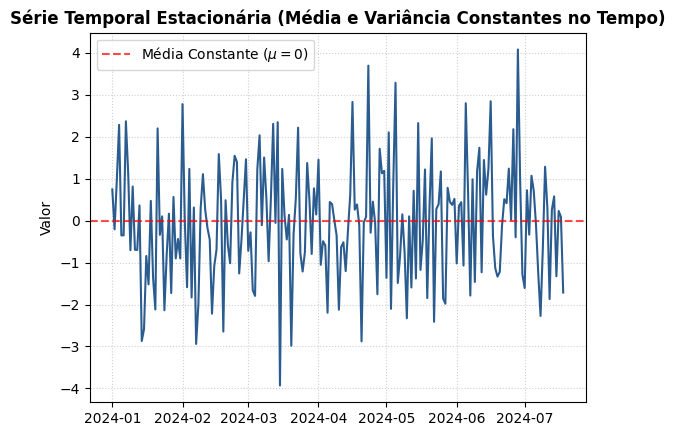

In [ ]:
plt.plot(serie_estacionaria.index, serie_estacionaria, color="#2b5c8f", linewidth=1.5)
plt.axhline(0, color="red", linestyle="--", alpha=0.7, label="Média Constante ($\mu = 0$)")
plt.title("Série Temporal Estacionária (Média e Variância Constantes no Tempo)", fontsize=12, fontweight="bold")
plt.ylabel("Valor")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)


## **Plot da  Série  Não Estacionária**

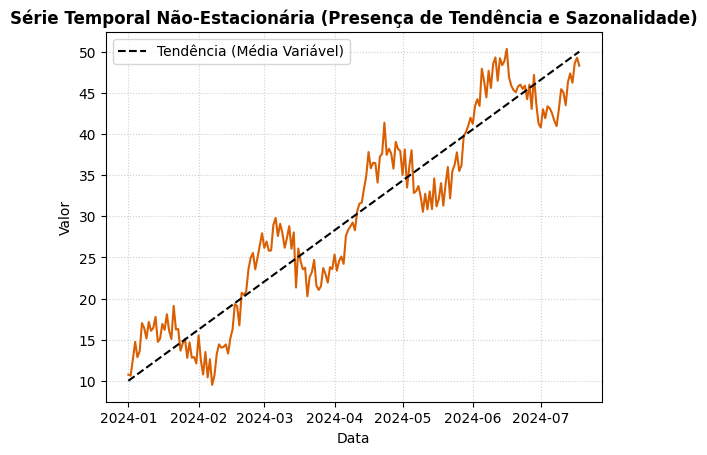

In [ ]:
plt.plot(serie_nao_estacionaria.index, serie_nao_estacionaria, color="#d95f02", linewidth=1.5)
plt.plot(serie_nao_estacionaria.index, tendencia, color="black", linestyle="--", label="Tendência (Média Variável)")
plt.title("Série Temporal Não-Estacionária (Presença de Tendência e Sazonalidade)", fontsize=12, fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()


# **Teste de Dickey-Fuller Aumentado (ADF)**

 **Objetivo:** Identificar a presença de Raiz Unitária na série.
* **Hipótese Nula ($H_0$):** A série possui raiz unitária (não é estacionária).
* **Hipótese Alternativa ($H_1$):** A série não possui raiz unitária (é estacionária).
* **Decisão:** Se $p\text{-valor} < 0{,}05$, rejeita-se $H_0 \implies$ A série é Estacionária.


## **Dickey-Fuller Aumentado (Statsmodels)**

A função **adfuller** do pacote **Statsmodels** retorna por padrão uma tupla contendo os principais resultados estatísticos do Teste Dickey-Fuller Aumentado.

**Valores de Retorno (Ordem da Tupla)**
* **Estatística do Teste (ADF Statistic) : float**  O valor calculado da estatística do teste. Quanto mais negativo for esse valor, maior será a evidência para rejeitar a hipótese nula.
*  **P-valor (p-value):float** O valor de probabilidade aproximado baseado nas tabelas de MacKinnon. Valores menores que o nível de significância (usualmente 0.05) indicam que a série é estacionária.

* **Número de Defasagens (Lags Usados): int** A quantidade de defasagens (lags) incluídas na regressão do teste.

* **Número de Observações (nobs): int** O total de observações efetivamente utilizado nos cálculos da regressão ADF.

* **Valores Críticos (Critical Values): dict** Um dicionário contendo os valores críticos da estatística para os níveis de significância de 1%, 5% e 10%

## **Avaliando a  estacionaridade (ADF)**

In [ ]:
result_adfuller= adfuller(serie_estacionaria, autolag='AIC')

/tmp/ipykernel_1187/1446077780.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_adfuller= adfuller(serie_estacionaria, autolag='AIC')


In [ ]:
print('Estatistica do teste: {:.4f}'.format(result_adfuller[0]))
print('p_valor: {:.4f}'.format(result_adfuller[1]))
print('Valores Críticos:')
for key, value in result_adfuller[4].items():
    print('\t{}: {:.4f}'.format(key, value))

Estatistica do teste: -14.7442
p_valor: 0.0000
Valores Críticos:
	1%: -3.4636
	5%: -2.8762
	10%: -2.5746


In [ ]:
print(f"[ADF]  Estatística: {result_adfuller[0]:.4f} | p-valor: {result_adfuller[1]:.4f} -> " +
          ("Estacionária (Rejeita H0)" if result_adfuller[1] < 0.05 else "Não-Estacionária (Falha em rejeitar H0)")),

[ADF]  Estatística: -14.7442 | p-valor: 0.0000 -> Estacionária (Rejeita H0)


(None,)

## **Avaliando a não estacionaridade (ADF)**

In [ ]:
result_adfuller= adfuller(serie_nao_estacionaria, autolag='AIC')

/tmp/ipykernel_1187/2610546243.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_adfuller= adfuller(serie_nao_estacionaria, autolag='AIC')


In [ ]:
print('Estatistica do teste: {:.4f}'.format(result_adfuller[0]))
print('p_valor: {:.4f}'.format(result_adfuller[1]))
print('Valores Críticos:')
for key, value in result_adfuller[4].items():
    print('\t{}: {:.4f}'.format(key, value))

Estatistica do teste: -0.7865
p_valor: 0.8231
Valores Críticos:
	1%: -3.4651
	5%: -2.8768
	10%: -2.5749


In [ ]:
print(f"[ADF]  Estatística: {result_adfuller[0]:.4f} | p-valor: {result_adfuller[1]:.4f} -> " +
          ("Estacionária (Rejeita H0)" if result_adfuller[1] < 0.05 else "Não-Estacionária (Falha em rejeitar H0)")),

[ADF]  Estatística: -0.7865 | p-valor: 0.8231 -> Não-Estacionária (Falha em rejeitar H0)


(None,)

#  **Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin**)
*  **Objetivo:** Avaliar se a série é estacionária em torno de um nível ou tendência.
* **Hipótese Nula ($H_0$):** A série é estacionária.
* **Hipótese Alternativa ($H_1$):** A série não é estacionária (possui raiz unitária).
* **Decisão:** Se $p\text{-valor} < 0{,}05$, rejeita-se $H_0 \implies$ A série é Não-Estacionária.

##  **KPSS (statsmodels.tsa.stattools)**


A função **kpss** do pacote **statsmodels.tsa.stattools** em Python retorna uma tupla com quatro valores principais: estatística do teste, p-valor, número de defasagens utilizadas e um dicionário com os valores críticos

**Parâmetros de Retorno**

* **kpss_stat (Estatística do teste):** O valor numérico calculado do teste KPSS. Valores altos indicam evidência contra a hipótese nula de estacionariedade.
* **p-value (Valor p):** O p-valor associado à estatística. No statsmodels, o p-valor é truncado nos limites de tabela (por exemplo, o menor valor reportado costuma ser 0.01 e o maior 0.1).
*  **lags (Número de defasagens):** O número de defasagens (lags) escolhido ou utilizado automaticamente pelo algoritmo para o cálculo da variância de longo prazo.
* **critical values (Valores críticos):** Um dicionário contendo os valores críticos para os níveis de significância de 10%, 5%, 2.5% e 1%.Se precisar, posso mostrar um exemplo prático em código de como desestruturar essa tupla e aplicar o teste em uma série temporal específica

### **Avaliando estacionaridade (KPSS)**

In [ ]:
result_kpss = kpss(serie_estacionaria, regression='c', nlags='auto')

/tmp/ipykernel_1187/4239806074.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  result_kpss = kpss(serie_estacionaria, regression='c', nlags='auto')
/tmp/ipykernel_1187/4239806074.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_kpss = kpss(serie_estacionaria, regression='c', nlags='auto')


In [ ]:
print('Estatistica do teste: {:.4f}'.format(result_kpss[0]))
print('p_valor: {:.4f}'.format(result_kpss[1]))
print('Valores Críticos:')
for key, value in result_kpss[3].items():
    print('\t{}: {:.4f}'.format(key, value))

Estatistica do teste: 0.1797
p_valor: 0.1000
Valores Críticos:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390


In [ ]:
print(f"[KPSS] Estatística: {result_kpss[0]:.4f} | p-valor: {result_kpss[1]:.4f} -> " +
          ("Não-Estacionária (Rejeita H0)" if result_kpss[1] < 0.05 else "Estacionária (Falha em rejeitar H0)"))

[KPSS] Estatística: 0.1797 | p-valor: 0.1000 -> Estacionária (Falha em rejeitar H0)


### **Avaliando a não estacionaridade (KPSS)**

In [ ]:
result_kpss = kpss(serie_nao_estacionaria, regression='c', nlags='auto')

/tmp/ipykernel_1187/2009211692.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  result_kpss = kpss(serie_nao_estacionaria, regression='c', nlags='auto')
/tmp/ipykernel_1187/2009211692.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_kpss = kpss(serie_nao_estacionaria, regression='c', nlags='auto')


In [ ]:
print('Estatistica do teste: {:.4f}'.format(result_kpss[0]))
print('p_valor: {:.4f}'.format(result_kpss[1]))
print('Valores Críticos:')
for key, value in result_kpss[3].items():
    print('\t{}: {:.4f}'.format(key, value))

Estatistica do teste: 1.9475
p_valor: 0.0100
Valores Críticos:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390


In [ ]:
print(f"[KPSS] Estatística: {result_kpss[0]:.4f} | p-valor: {result_kpss[1]:.4f} -> " +
          ("Não-Estacionária (Rejeita H0)" if result_kpss[1] < 0.05 else "Estacionária (Falha em rejeitar H0)"))

[KPSS] Estatística: 1.9475 | p-valor: 0.0100 -> Não-Estacionária (Rejeita H0)
